In [1]:
import pymc
import yfinance
import numpy
import matplotlib.pyplot

In [2]:
dados = yfinance.download("BOVA11.SA", start="2022-01-01", end="2026-01-01")

precos_fechamento = dados['Close'].values.flatten()
log_retornos = numpy.log(precos_fechamento[1:] / precos_fechamento[:-1])
log_retornos = log_retornos[~numpy.isnan(log_retornos)]

[*********************100%***********************]  1 of 1 completed


In [3]:
with pymc.Model() as modelo:
    mu = pymc.Normal("mu", mu=0.0, sigma=0.05)
    sigma = pymc.HalfNormal("sigma", sigma=0.05)
    nu = pymc.Exponential("nu", lam=1/10.0)

    verossimilhanca = pymc.StudentT("retornos", nu=nu, mu=mu, sigma=sigma, observed=log_retornos)

    traco = pymc.sample(draws=2000, tune=1000, chains=2, return_inferencedata=True)

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━ ━━━━━━━━━━━━━   2000        0           0.577       7           1381.23 draws/s      0:00:02    0:00:00   
  ━━━━━━ ━━━━━━━━━━━━━   2000        0           0.656       7           1265.51 draws/s      0:00:02    0:00:00

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 5 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [4]:
mu_amostras = numpy.asarray(traco.posterior["mu"]).flatten()
sigma_amostras = numpy.asarray(traco.posterior["sigma"]).flatten()
nu_amostras = numpy.asarray(traco.posterior["nu"]).flatten()

In [5]:
for nome, amostras in [("mu", mu_amostras), ("sigma", sigma_amostras), ("nu", nu_amostras)]:
    media = numpy.mean(amostras)
    q25, q975 = numpy.percentile(amostras, [2.5, 97.5])
    print(f"{nome}: Média = {media:.6f} | IC 95% = [{q25:.6f}, {q975:.6f}]")

mu: Média = 0.000527 | IC 95% = [-0.000116, 0.001195]
sigma: Média = 0.009490 | IC 95% = [0.008808, 0.010217]
nu: Média = 7.960911 | IC 95% = [5.074380, 13.283157]


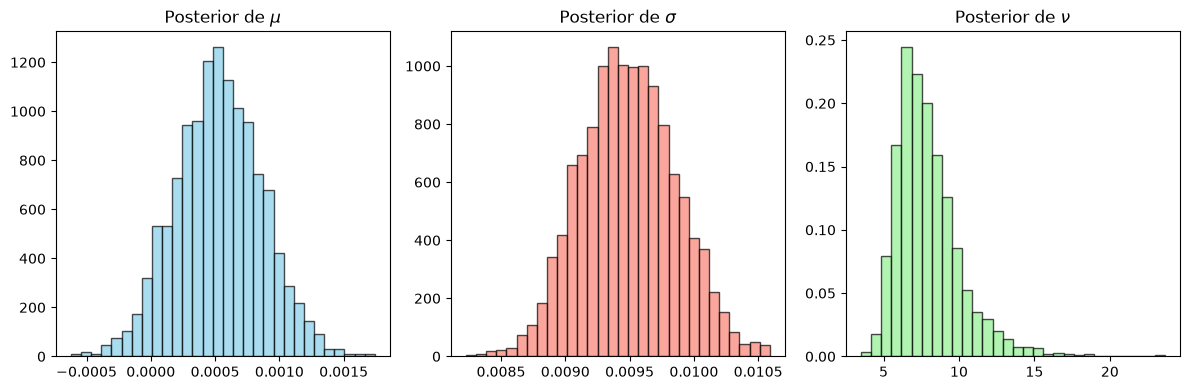

In [6]:
figura, eixos = matplotlib.pyplot.subplots(1, 3, figsize=(12, 4))

eixos[0].hist(mu_amostras, bins=30, density=True, alpha=0.7, color="skyblue", edgecolor="black")
eixos[0].set_title(r"Posterior de $\mu$")

eixos[1].hist(sigma_amostras, bins=30, density=True, alpha=0.7, color="salmon", edgecolor="black")
eixos[1].set_title(r"Posterior de $\sigma$")

eixos[2].hist(nu_amostras, bins=30, density=True, alpha=0.7, color="lightgreen", edgecolor="black")
eixos[2].set_title(r"Posterior de $\nu$")

matplotlib.pyplot.tight_layout()
matplotlib.pyplot.show()